### **Data Loading**

In [ ]:
# Importing necessary libraries for data analysis and visualization
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder    # Library for encoding categorical variables

# Suppressing warnings to prevent unnecessary output during execution
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit     # Split data into training and testing sets
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score     # Import evaluation metrics to measure model performance
from sklearn.pipeline import Pipeline     # Create a machine learning pipeline
from sklearn.impute import SimpleImputer     # Handle missing values by imputing them
from sklearn.preprocessing import StandardScaler     # Standardize features
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV     # Tools for time series cross-validation and hyperparameter tuning

In [ ]:
# Import Regression Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Dimensionality reduction techniques
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

In [ ]:
# Reading the dataset CSV file into a Pandas DataFrame
df = pd.read_csv('/content/Air Quality.csv')
df.head()      # display 5 first rows from dataset

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


### **Data Cleaning and Preprocessing**

####Cleaning Data

In [ ]:
df.info()     # Displaying a summary of the dataset
df.describe(include="all").T.head(30)     # Display statistics description

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,9357,391,03/04/2005,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9357,24,18:00:00,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO(GT),9357.0,NaN,NaN,NaN,-34.207524,77.65717,-200.0,0.6,1.5,2.6,11.9
PT08.S1(CO),9357.0,NaN,NaN,NaN,1048.990061,329.83271,-200.0,921.0,1053.0,1221.0,2040.0
NMHC(GT),9357.0,NaN,NaN,NaN,-159.090093,139.789093,-200.0,-200.0,-200.0,-200.0,1189.0
C6H6(GT),9357.0,NaN,NaN,NaN,1.865683,41.380206,-200.0,4.0,7.9,13.6,63.7
PT08.S2(NMHC),9357.0,NaN,NaN,NaN,894.595276,342.333252,-200.0,711.0,895.0,1105.0,2214.0
NOx(GT),9357.0,NaN,NaN,NaN,168.616971,257.433866,-200.0,50.0,141.0,284.0,1479.0
PT08.S3(NOx),9357.0,NaN,NaN,NaN,794.990168,321.993552,-200.0,637.0,794.0,960.0,2683.0
NO2(GT),9357.0,NaN,NaN,NaN,58.148873,126.940455,-200.0,53.0,96.0,133.0,340.0


In [ ]:
# remove columns that start with unnamed
unnamed_columns = [c for c in df.columns if str(c).startswith("Unnamed")]
data = df.drop(columns=unnamed_columns, errors="ignore")

print("Dropped columns:", unnamed_columns)
print("Shape after drop:", data.shape)
data.columns     # Display columns

Dropped columns: ['Unnamed: 15', 'Unnamed: 16']
Shape after drop: (9471, 15)


Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [ ]:
data = data.replace(-200, np.nan)     # replace -200 with NaN, it presents missing values

data = data.dropna(how="all")     # Remove rows that are completely empty (all NaN)
print("Shape after cleaning missing values and empty rows:", data.shape)

Shape after cleaning missing values and empty rows: (9357, 15)


In [ ]:
# Check missing values count
data.isna().sum().sort_values(ascending=False).head(15)

,0
NMHC(GT),8443
CO(GT),1683
NO2(GT),1642
NOx(GT),1639
PT08.S2(NMHC),366
C6H6(GT),366
PT08.S1(CO),366
PT08.S5(O3),366
T,366
PT08.S3(NOx),366


In [ ]:
# identify and remove duplicates values
data.drop_duplicates()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,04/04/2005,11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13:00:00,2.1,1003.0,NaN,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


In [ ]:
# create a single datetime column
if "Date" in data.columns and "Time" in data.columns:
    data["Datetime"] = pd.to_datetime(
        data["Date"].astype(str) + " " + data["Time"].astype(str),
        errors="coerce",
        dayfirst=True     # common for this dataset format (dd/mm/yyyy)
    )
elif "Datetime" in data.columns:
    data["Datetime"] = pd.to_datetime(data["Datetime"], errors="coerce")
else:
    raise ValueError("No Date/Time columns found to build a Datetime column.")

In [ ]:
data = data.dropna(subset=["Datetime"]).copy()     # Drop rows where datetime couldn't be parsed
data = data.sort_values("Datetime").reset_index(drop=True)     # Sort by time

print("Datetime range:", data["Datetime"].min(), "->", data["Datetime"].max())
data[["Datetime"]].head()

Datetime range: 2004-03-10 18:00:00 -> 2005-04-04 14:00:00


,Datetime
0,2004-03-10 18:00:00
1,2004-03-10 19:00:00
2,2004-03-10 20:00:00
3,2004-03-10 21:00:00
4,2004-03-10 22:00:00


####Target Definition

In [ ]:
# Define Target and Remove Target Missing Rows
TARGET = "CO(GT)"

if TARGET not in data.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Available columns: {list(data.columns)}")

data = data.dropna(subset=[TARGET]).copy()     # Remove rows where target is missing

print("Shape after dropping missing target rows:", data.shape)
data[[TARGET]].describe()

Shape after dropping missing target rows: (7674, 16)


,CO(GT)
count,7674.000000
mean,2.152750
std,1.453252
min,0.100000
25%,1.100000
50%,1.800000
75%,2.900000
max,11.900000


####Future Engineering

In [ ]:
# Time-Based Feature Engineering

# Extract useful time-based features from Datetime
data["hour"] = data["Datetime"].dt.hour
data["day"] = data["Datetime"].dt.day
data["month"] = data["Datetime"].dt.month
data["weekday"] = data["Datetime"].dt.weekday  # Monday=0, Sunday=6

data["is_weekend"] = data["weekday"].isin([5, 6]).astype(int)
data[["Datetime", "hour", "day", "month", "weekday", "is_weekend"]].head()

,Datetime,hour,day,month,weekday,is_weekend
0,2004-03-10 18:00:00,18,10,3,2,0
1,2004-03-10 19:00:00,19,10,3,2,0
2,2004-03-10 20:00:00,20,10,3,2,0
3,2004-03-10 21:00:00,21,10,3,2,0
4,2004-03-10 22:00:00,22,10,3,2,0


####Lag and Rolling Features

In [ ]:
# create lag and rolling features for the target
LAG_HOURS = [1, 2, 3]
ROLLING_WINDOWS = [3, 24]  # hours

In [ ]:
# Columns to create lag/rolling features for
sensor_cols = [
    "CO(GT)",
    "NO2(GT)",
    "NOx(GT)",
    "C6H6(GT)"
]
for col in sensor_cols:
    if col in data.columns:
        for lag in LAG_HOURS:     # Lag features
            data[f"{col}_lag_{lag}"] = data[col].shift(lag)
        for window in ROLLING_WINDOWS:     # Rolling mean features
            data[f"{col}_roll_mean_{window}"] = (
                data[col]
                .rolling(window=window, min_periods=1)
                .mean()
            )

In [ ]:
# Check newly created columns
new_features = [c for c in data.columns if "lag" in c or "roll" in c]

print("Number of new features:", len(new_features))
data[new_features].head(10)

Number of new features: 20


,CO(GT)_lag_1,CO(GT)_lag_2,CO(GT)_lag_3,CO(GT)_roll_mean_3,CO(GT)_roll_mean_24,NO2(GT)_lag_1,NO2(GT)_lag_2,NO2(GT)_lag_3,NO2(GT)_roll_mean_3,NO2(GT)_roll_mean_24,NOx(GT)_lag_1,NOx(GT)_lag_2,NOx(GT)_lag_3,NOx(GT)_roll_mean_3,NOx(GT)_roll_mean_24,C6H6(GT)_lag_1,C6H6(GT)_lag_2,C6H6(GT)_lag_3,C6H6(GT)_roll_mean_3,C6H6(GT)_roll_mean_24
0,NaN,NaN,NaN,2.600000,2.600000,NaN,NaN,NaN,113.000000,113.000000,NaN,NaN,NaN,166.000000,166.000000,NaN,NaN,NaN,11.900000,11.900000
1,2.6,NaN,NaN,2.300000,2.300000,113.0,NaN,NaN,102.500000,102.500000,166.0,NaN,NaN,134.500000,134.500000,11.9,NaN,NaN,10.650000,10.650000
2,2.0,2.6,NaN,2.266667,2.266667,92.0,113.0,NaN,106.333333,106.333333,103.0,166.0,NaN,133.333333,133.333333,9.4,11.9,NaN,10.100000,10.100000
3,2.2,2.0,2.6,2.133333,2.250000,114.0,92.0,113.0,109.333333,110.250000,131.0,103.0,166.0,135.333333,143.000000,9.0,9.4,11.9,9.200000,9.875000
4,2.2,2.2,2.0,2.000000,2.120000,122.0,114.0,92.0,117.333333,111.400000,172.0,131.0,103.0,144.666667,140.600000,9.2,9.0,9.4,8.233333,9.200000
5,1.6,2.2,2.2,1.666667,1.966667,116.0,122.0,114.0,111.333333,108.833333,131.0,172.0,131.0,130.666667,132.000000,6.5,9.2,9.0,6.800000,8.450000
6,1.2,1.6,2.2,1.333333,1.857143,96.0,116.0,122.0,96.333333,104.285714,89.0,131.0,172.0,94.000000,122.000000,4.7,6.5,9.2,4.933333,7.757143
7,1.2,1.2,1.6,1.133333,1.750000,77.0,96.0,116.0,83.000000,100.750000,62.0,89.0,131.0,71.000000,114.500000,3.6,4.7,6.5,3.866667,7.200000
8,1.0,1.2,1.2,1.033333,1.655556,76.0,77.0,96.0,71.000000,96.222222,62.0,62.0,89.0,56.333333,106.777778,3.3,3.6,4.7,3.066667,6.655556
9,0.9,1.0,1.2,0.833333,1.550000,60.0,76.0,77.0,68.000000,96.222222,45.0,62.0,62.0,53.500000,106.777778,2.3,3.3,3.6,2.433333,6.160000


In [ ]:
before_rows = df.shape[0]     # remove Rows with NaNs from Lag Features

data = data.dropna().reset_index(drop=True)     # Drop rows with any remaining NaNs (mostly from lag features)

after_rows = data.shape[0]

print(f"Rows before dropping lag NaNs: {before_rows}")
print(f"Rows after dropping lag NaNs : {after_rows}")
print(f"Dropped rows               : {before_rows - after_rows}")

Rows before dropping lag NaNs: 9471
Rows after dropping lag NaNs : 710
Dropped rows               : 8761


In [ ]:
data     # Display Dataset

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),...,NOx(GT)_lag_1,NOx(GT)_lag_2,NOx(GT)_lag_3,NOx(GT)_roll_mean_3,NOx(GT)_roll_mean_24,C6H6(GT)_lag_1,C6H6(GT)_lag_2,C6H6(GT)_lag_3,C6H6(GT)_roll_mean_3,C6H6(GT)_roll_mean_24
0,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,...,131.0,103.0,166.0,135.333333,143.000000,9.0,9.4,11.9,9.200000,9.875000
1,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,...,172.0,131.0,103.0,144.666667,140.600000,9.2,9.0,9.4,8.233333,9.200000
2,10/03/2004,23:00:00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,...,131.0,172.0,131.0,130.666667,132.000000,6.5,9.2,9.0,6.800000,8.450000
3,11/03/2004,00:00:00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,...,89.0,131.0,172.0,94.000000,122.000000,4.7,6.5,9.2,4.933333,7.757143
4,11/03/2004,01:00:00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,...,62.0,89.0,131.0,71.000000,114.500000,3.6,4.7,6.5,3.866667,7.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705,30/04/2004,20:00:00,4.4,1449.0,501.0,19.5,1282.0,254.0,625.0,133.0,...,281.0,215.0,215.0,250.000000,182.913043,26.9,21.0,19.2,22.466667,14.812500
706,30/04/2004,21:00:00,3.1,1363.0,234.0,15.1,1152.0,189.0,684.0,110.0,...,254.0,281.0,215.0,241.333333,180.478261,19.5,26.9,21.0,20.500000,14.641667
707,30/04/2004,22:00:00,3.0,1371.0,212.0,14.6,1136.0,174.0,689.0,102.0,...,189.0,254.0,281.0,205.666667,180.217391,15.1,19.5,26.9,16.400000,14.570833
708,30/04/2004,23:00:00,3.1,1406.0,275.0,13.7,1107.0,167.0,718.0,108.0,...,174.0,189.0,254.0,176.666667,180.695652,14.6,15.1,19.5,14.466667,14.570833


####Futear Selection

In [ ]:
TARGET = "CO(GT)"
drop_cols = ["Date", "Time", "Datetime", TARGET]

# Build feature matrix X and target vector y
X = data.drop(columns=[c for c in drop_cols if c in data.columns], errors="ignore")
y = data[TARGET].copy()

X = X.select_dtypes(include=[np.number])     # Keep only numeric features

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTop feature columns:")
print(list(X.columns)[:20])

X shape: (710, 37)
y shape: (710,)

Top feature columns:
['PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'CO(GT)_lag_1', 'CO(GT)_lag_2', 'CO(GT)_lag_3']


In [ ]:
split_ratio = 0.8     # Define the proportion of data to be used for training
split_idx = int(len(data) * split_ratio)

# Split features and target into training and test sets
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("\nTrain size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 568 Test size: 142



### **Exploratory Data Analysis**

####Continuous Visualization

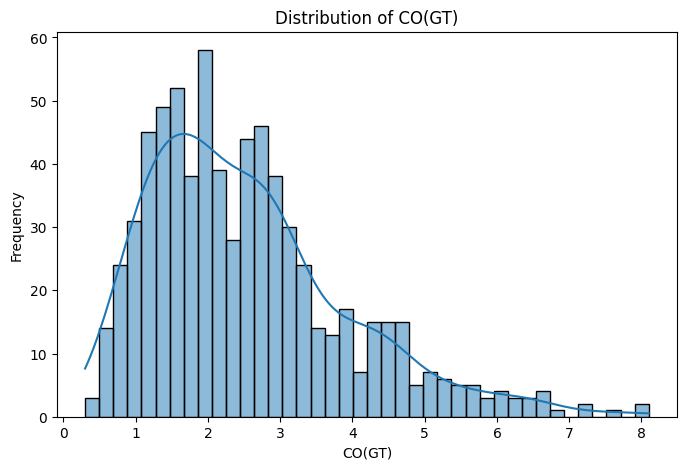

count    710.000000
mean       2.536197
std        1.382502
min        0.300000
25%        1.500000
50%        2.300000
75%        3.200000
max        8.100000
Name: CO(GT), dtype: float64


In [ ]:
# Method to plot the distribution of each continuous variable
plt.figure(figsize=(8, 5))
sb.histplot(data["CO(GT)"], bins=40, kde=True)
plt.title("Distribution of CO(GT)")
plt.xlabel("CO(GT)")
plt.ylabel("Frequency")
plt.show()
print(data["CO(GT)"].describe())

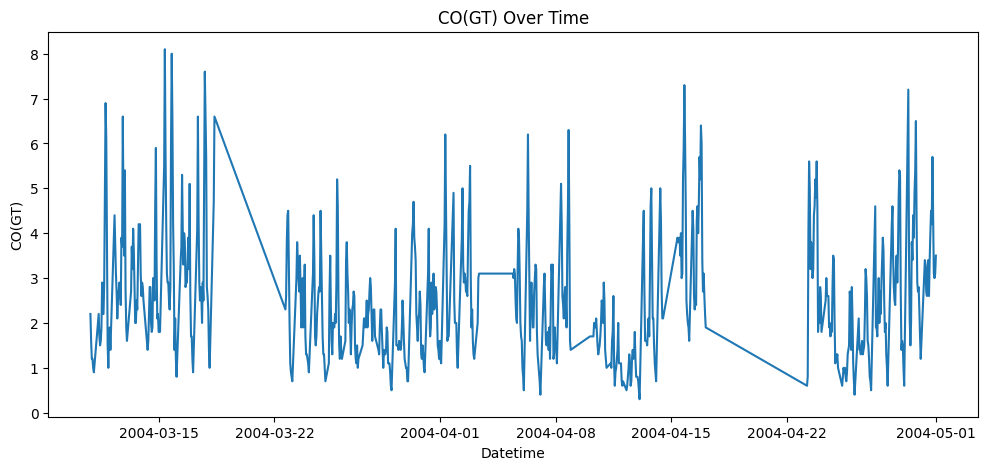

In [ ]:
# Visualization to find Overall Trend and seasonal behavior
plt.figure(figsize=(12, 5))
sb.lineplot(data=data, x="Datetime", y="CO(GT)")
plt.title("CO(GT) Over Time")
plt.xlabel("Datetime")
plt.ylabel("CO(GT)")
plt.show()

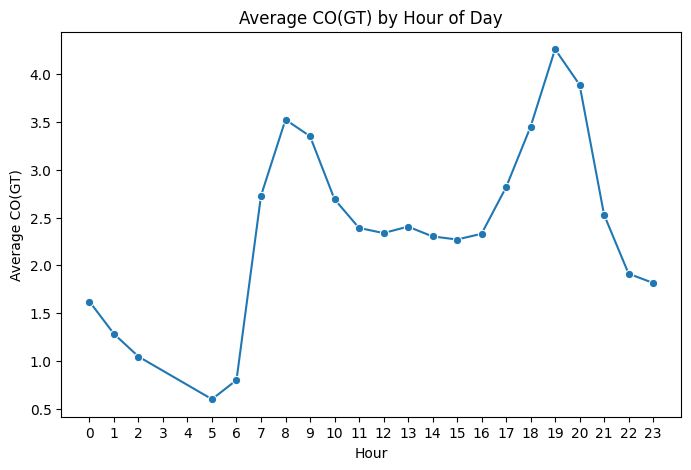

In [ ]:
# Line Plot for Average CO by Hour of Day

# Calculate the average CO(GT) concentration for each hour of the day
hourly_mean = (data.groupby("hour", as_index=False)["CO(GT)"].mean())

# Plot
plt.figure(figsize=(8, 5))
sb.lineplot(
    data=hourly_mean,
    x="hour",
    y="CO(GT)",
    marker="o",
)
plt.title("Average CO(GT) by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average CO(GT)")
plt.xticks(range(0, 24))
plt.show()

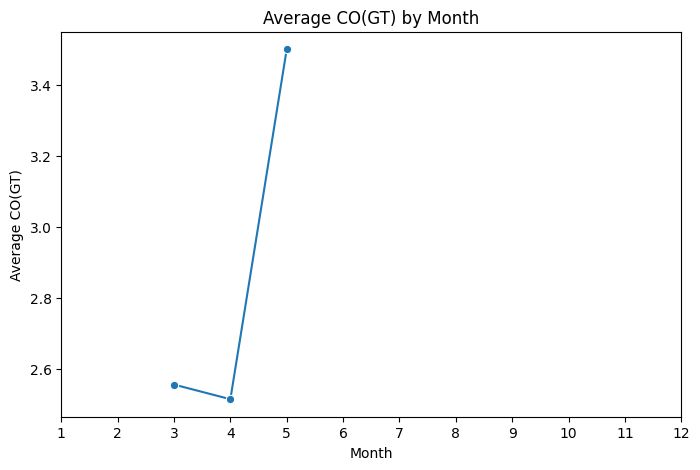

In [ ]:
# Line plot for Average CO by Month

# we can find seasonal effects
monthly_mean = (data.groupby("month", as_index=False)["CO(GT)"].mean())

# Plot
plt.figure(figsize=(8, 5))
sb.lineplot(
    data=monthly_mean,
    x="month",
    y="CO(GT)",
    marker="o",
)
plt.title("Average CO(GT) by Month")
plt.xlabel("Month")
plt.ylabel("Average CO(GT)")
plt.xticks(range(1, 13))
plt.show()

In [ ]:
# Correlation with CO(GT)
corr = data.corr(numeric_only=True)["CO(GT)"].sort_values(ascending=False)

print("Top positive correlations:")
print(corr.head(10))

print("\nTop negative correlations:")
print(corr.tail(10))     # display 10 last rowes from dataset

Top positive correlations:
CO(GT)                  1.000000
C6H6(GT)                0.969662
PT08.S2(NMHC)           0.955704
NOx(GT)                 0.949451
PT08.S4(NO2)            0.943011
PT08.S1(CO)             0.930198
PT08.S5(O3)             0.880547
NMHC(GT)                0.873263
NO2(GT)                 0.851086
C6H6(GT)_roll_mean_3    0.831969
Name: CO(GT), dtype: float64

Top negative correlations:
NOx(GT)_lag_3     0.207634
C6H6(GT)_lag_3    0.206721
CO(GT)_lag_3      0.155878
NO2(GT)_lag_3     0.155173
RH                0.000466
month            -0.011901
weekday          -0.023743
day              -0.069521
is_weekend       -0.196691
PT08.S3(NOx)     -0.837584
Name: CO(GT), dtype: float64


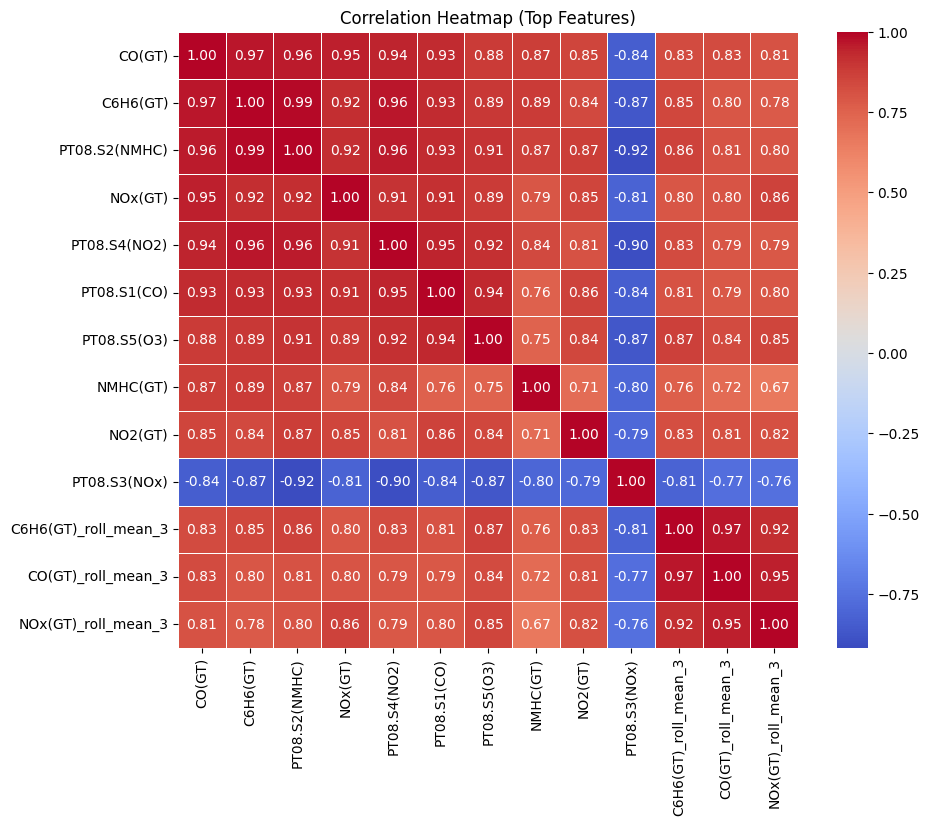

In [ ]:
# Correlation Heatmap
top_features = corr.drop("CO(GT)").abs().sort_values(ascending=False).head(12).index.tolist()
heatmap_features = ["CO(GT)"] + top_features

# Plot
plt.figure(figsize=(10, 8))
sb.heatmap(data[heatmap_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap (Top Features)")
plt.show()

Chi-square test was not applied because the target variable is continuous
and the test is only suitable for categorical variables.


####Categorical Visualization

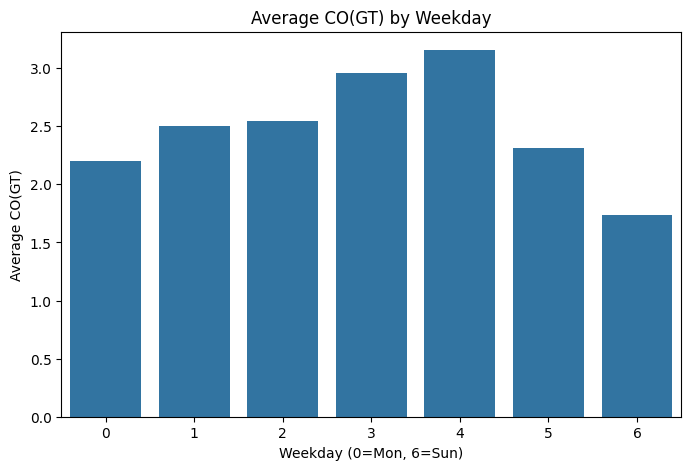

In [ ]:
# Bar plot for CO(GT) by Weekday
weekday_mean = (data.groupby("weekday", as_index=False)["CO(GT)"].mean())

# Plot
plt.figure(figsize=(8, 5))
sb.barplot(data=weekday_mean, x="weekday", y="CO(GT)")
plt.title("Average CO(GT) by Weekday")
plt.xlabel("Weekday (0=Mon, 6=Sun)")
plt.ylabel("Average CO(GT)")
plt.show()

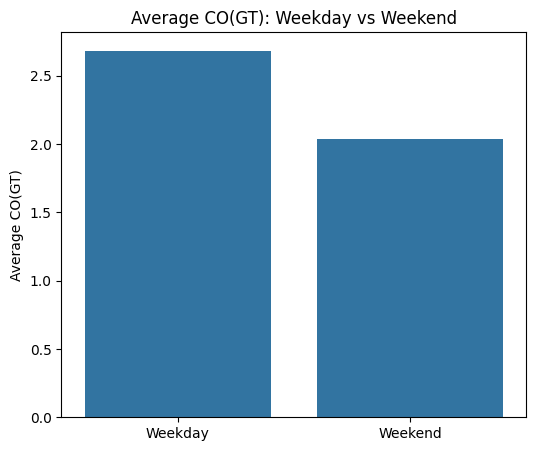

In [ ]:
# Bar plot for CO(GT) by Weekend
weekend_mean = data.groupby("is_weekend", as_index=False)["CO(GT)"].mean()
weekend_mean["DayType"] = weekend_mean["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})
# Plot
plt.figure(figsize=(6, 5))
sb.barplot(
    data=weekend_mean,
    x="DayType",
    y="CO(GT)",
    errorbar=None
)
plt.title("Average CO(GT): Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Average CO(GT)")
plt.show()

### **Machine Learning Model**

In [ ]:
# Common regression metrics.
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),     # average absoloute difference between values fitted by model and observed data.
        "RMSE": mean_squared_error(y_true, y_pred),     # squared root of MSE
        "R2": r2_score(y_true, y_pred),     # amount of variance in the dependant variable that the independant variable can explain.
        "MSE": mean_squared_error(y_true, y_pred)    # sum of squared difference between  the values fitted and observed.
    }

In [ ]:
# For models that need scaling (Ridge/Lasso/KNN/SVR)
scaled_pipeline_prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# For tree-based models
tree_pipeline_prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

####Ridge Regression

In [ ]:
# Train
ridge_model = Pipeline(steps=[
    ("prep", scaled_pipeline_prep),
    ("model", Ridge(alpha=1.0, random_state=42))
])

ridge_model.fit(X_train, y_train)     # Fit (train) the pipeline on the training data

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', Ridge(random_state=42))])

In [ ]:
# Predict
y_predict = ridge_model.predict(X_test)
y_predict[:10]

array([4.7027503 , 5.27745961, 4.92046309, 5.74192075, 4.37512897,
       1.90818773, 2.23345039, 2.04586832, 2.66388985, 2.581249  ])

In [ ]:
# Evaluate
ridge_regression = {"model": "Ridge", **regression_metrics(y_test, y_predict)}
pd.DataFrame([ridge_regression])

,model,MAE,RMSE,R2,MSE
0,Ridge,0.077464,0.009519,0.994872,0.009519


####Lasso Regression

In [ ]:
# Train
lasso_model = Pipeline(steps=[
    ("prep", scaled_pipeline_prep),
    ("model", Lasso(alpha=0.001, random_state=42, max_iter=5000))
])

lasso_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', Lasso(alpha=0.001, max_iter=5000, random_state=42))])

In [ ]:
#Predict
y_predict = lasso_model.predict(X_test)
y_predict[:10]

array([4.61969993, 5.23043548, 4.8195212 , 5.62204634, 4.52052666,
       1.84928876, 2.22089011, 2.02258817, 2.76141512, 2.60970647])

In [ ]:
# Evaluate
lasso_regression = {"model": "Lasso", **regression_metrics(y_test, y_predict)}
pd.DataFrame([lasso_regression])

,model,MAE,RMSE,R2,MSE
0,Lasso,0.025507,0.001007,0.999458,0.001007


####KNN Regression

In [ ]:
# Train
knn_model = Pipeline(steps=[
    ("prep", scaled_pipeline_prep),
    ("model", KNeighborsRegressor(n_neighbors=15, weights="distance"))
])

knn_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 KNeighborsRegressor(n_neighbors=15, weights='distance'))])

In [ ]:
# Predict
y_predict = knn_model.predict(X_test)
y_predict[:10]

array([4.20987859, 4.77191908, 4.58231597, 5.17309086, 4.50079524,
       2.46177157, 2.34203643, 2.338427  , 2.4156727 , 2.18052611])

In [ ]:
# Evaluate
knn_regression = {"model":"KNN", **regression_metrics(y_test, y_predict)}
pd.DataFrame([knn_regression])

,model,MAE,RMSE,R2,MSE
0,KNN,0.289084,0.133131,0.92828,0.133131


####SVR (Support Vector Regression)

In [ ]:
# Train
svr_model = Pipeline(steps=[
    ("prep", scaled_pipeline_prep),
    ("model", SVR(kernel="rbf", epsilon=0.1))
    ])
svr_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', SVR())])

In [ ]:
#Predict
y_predict=svr_model.predict(X_test)
y_predict[:10]

array([4.40635376, 4.99027865, 4.59283453, 5.15543973, 4.16078103,
       2.02637561, 2.35318056, 2.49627892, 2.67642822, 2.61839723])

In [ ]:
#Evaluate
svr_regression = {"model":"SVR", **regression_metrics(y_test, y_predict)}
pd.DataFrame([svr_regression])

,model,MAE,RMSE,R2,MSE
0,SVR,0.208543,0.079708,0.95706,0.079708


####DecisionTreeRegressor

In [ ]:
# Train
regression_tree_model = Pipeline(steps=[
    ("prep", tree_pipeline_prep),
    ("model", DecisionTreeRegressor(max_depth=12, random_state=42))     # random_state=42 → reproducibility
    ])
regression_tree_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(strategy='median'))])),
                ('model',
                 DecisionTreeRegressor(max_depth=12, random_state=42))])

In [ ]:
# Predict
y_predict = regression_tree_model.predict(X_test)
y_predict[:10]

array([4.4, 6.3, 5.2, 7.3, 4.9, 2. , 2.7, 2.4, 2.8, 2.7])

In [ ]:
# Evaluate
regression_tree_res = {"model": "RegressionTree", **regression_metrics(y_test, y_predict)}
pd.DataFrame([regression_tree_res])

,model,MAE,RMSE,R2,MSE
0,RegressionTree,0.362676,0.273592,0.852612,0.273592


####Random Forest Regressor

In [ ]:
# Train
rf_model = Pipeline(steps=[
    ("prep", tree_pipeline_prep),
    ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))      # n_estimators=400 → number of trees in the forest
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(strategy='median'))])),
                ('model',
                 RandomForestRegressor(n_estimators=400, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# Train
y_pred = rf_model.predict(X_test)
y_pred[:10]

array([4.93225, 5.87575, 5.37675, 6.305  , 4.591  , 2.135  , 2.4725 ,
       2.39475, 2.775  , 2.63975])

In [ ]:
# Evaluate
rf_regression = {"model": "RandomForest", **regression_metrics(y_test, y_pred)}
pd.DataFrame([rf_regression])

,model,MAE,RMSE,R2,MSE
0,RandomForest,0.241616,0.103672,0.94415,0.103672


####Gradient Boosting Regressor

In [ ]:
# Train
gb_model = Pipeline(steps=[
    ("prep", tree_pipeline_prep),
    ("model", GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42     # learning_rate=0.05 → contribution of each tree
    ))
])

gb_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(strategy='median'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=400,
                                           random_state=42))])

In [ ]:
# Predict
y_pred = gb_model.predict(X_test)
y_pred[:10]

array([4.82950314, 5.86028492, 5.42439475, 6.39388968, 4.47243424,
       2.09251325, 2.44270158, 2.30122939, 2.74966576, 2.62399252])

In [ ]:
# Evaluate
gb_regression = {"model": "Boosting(GBR)", **regression_metrics(y_test, y_pred)}
pd.DataFrame([gb_regression])

,model,MAE,RMSE,R2,MSE
0,Boosting(GBR),0.198051,0.065573,0.964675,0.065573


####All Regression Results

In [ ]:
results_data = pd.DataFrame([ridge_regression, lasso_regression, knn_regression, svr_regression, regression_tree_res, rf_regression, gb_regression])
results_data.sort_values("RMSE")

,model,MAE,RMSE,R2,MSE
1,Lasso,0.025507,0.001007,0.999458,0.001007
0,Ridge,0.077464,0.009519,0.994872,0.009519
6,Boosting(GBR),0.198051,0.065573,0.964675,0.065573
3,SVR,0.208543,0.079708,0.957060,0.079708
5,RandomForest,0.241616,0.103672,0.944150,0.103672
2,KNN,0.289084,0.133131,0.928280,0.133131
4,RegressionTree,0.362676,0.273592,0.852612,0.273592


### **Model Evaluation**

#### Pipelines

In [ ]:
# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

#### Pipelines(Ridge Regression)

In [ ]:
# Pipelines for ridge regression that require scaling
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

#### Pipelines(Lasso Regression)

In [ ]:
# Pipelines for lasso regression that require scaling
lasso_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),     # Replaces missing values with the median of each feature
    ("scaler", StandardScaler()),     # Feature scaling
    ("model", Lasso(alpha=0.001, random_state=42, max_iter=5000))      # max_iter=5000 → ensures convergence
])

#### Pipelines(KNN Regression)

In [ ]:
# Pipelines for KNN regression that require scaling
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=15, weights="distance"))
])

#### Pipelines(SVR Regression)

In [ ]:
# Pipelines for svr regression that require scaling
svr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
])

#### Pipelines(Desicion Tree Regression)

In [ ]:
# Pipelines for Desicion Tree regression
regressiontree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeRegressor(max_depth=12, random_state=42))     # max_depth=12 → limits tree depth to control overfitting
])

#### Pipelines(Random Forest Regression)



In [ ]:
# Pipelines for Random Forest regression
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

#### Pipelines(Boosting)

In [ ]:
# Pipelines for Boosting
gbr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42))
])

####Pipeline(Result)

In [ ]:
models = {
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "KNN": knn_pipeline,
    "SVR": svr_pipeline,
    "RegressionTree": regressiontree_pipeline,
    "RandomForest": rf_pipeline,
    "GradientBoosting": gbr_pipeline
}

In [ ]:
# TimeSeries Cross Validation for ALL Models
cv_rows = []     # List to store cross-validation results for each model

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train, y_train,
        cv=tscv,     # TimeSeriesSplit object
        scoring=scoring,     # Dictionary of scoring metrics
        n_jobs=-1
    )
    cv_rows.append({
        "model": name,
        "MAE_mean": -scores["test_MAE"].mean(),
        "RMSE_mean": -scores["test_RMSE"].mean(),
        "R2_mean": scores["test_R2"].mean()
    })

In [ ]:
cv_results_data = pd.DataFrame(cv_rows).sort_values("RMSE_mean")
cv_results_data

,model,MAE_mean,RMSE_mean,R2_mean
1,Lasso,0.032236,0.045547,0.998450
0,Ridge,0.153393,0.200829,0.966703
6,GradientBoosting,0.203438,0.273470,0.951588
5,RandomForest,0.220079,0.291318,0.945720
4,RegressionTree,0.290000,0.406185,0.890656
2,KNN,0.336826,0.427834,0.879065
3,SVR,0.396552,0.515215,0.771494


In [ ]:
top2 = cv_results_data.head(2)    # Select Top Models for GridSearch
top2

,model,MAE_mean,RMSE_mean,R2_mean
1,Lasso,0.032236,0.045547,0.998450
0,Ridge,0.153393,0.200829,0.966703


####GridSearch for Lasso

In [ ]:
# GridSearch for Lasso
tscv = TimeSeriesSplit(n_splits=5)

lasso_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(random_state=42, max_iter=20000))
])

In [ ]:
# Hyperparameter grid for tuning the Lasso regression model
lasso_param_grid = {
    "model__alpha": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
}

In [ ]:
# Set up GridSearchCV for tuning the Lasso regression model
lasso_gridsearch = GridSearchCV(
    estimator=lasso_pipeline,     # Pipeline to be tuned
    param_grid=lasso_param_grid,     # Hyperparameter grid
    scoring="neg_root_mean_squared_error",     # Optimization metric
    cv=tscv,
    n_jobs=-1
)
lasso_gridsearch.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        Lasso(max_iter=20000,
                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__alpha': [1e-05, 3e-05, 0.0001, 0.0003, 0.001,
                                          0.003, 0.01, 0.03, 0.1]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print("Best Lasso Params:", lasso_gridsearch.best_params_)
print("Best Lasso CV RMSE:", -lasso_gridsearch.best_score_)

Best Lasso Params: {'model__alpha': 3e-05}
Best Lasso CV RMSE: 0.0014152903587302899


####GridSearch for Ridge

In [ ]:
# GridSearch for Ridge
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(random_state=42))
])

In [ ]:
ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

In [ ]:
ridge_gridsearch = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)
ridge_gridsearch.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model', Ridge(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print("Best Ridge Params:", ridge_gridsearch.best_params_)
print("Best Ridge CV RMSE:", -ridge_gridsearch.best_score_)

Best Ridge Params: {'model__alpha': 0.001}
Best Ridge CV RMSE: 0.0016598028050902017


####Compare Tuned Models (Lasso vs Ridge)

In [ ]:
tuned_compare = pd.DataFrame([
    {"model": "Lasso (GridSearch)", "CV_RMSE": -lasso_gridsearch.best_score_, "best_params": lasso_gridsearch.best_params_},
    {"model": "Ridge (GridSearch)", "CV_RMSE": -ridge_gridsearch.best_score_, "best_params": ridge_gridsearch.best_params_}
]).sort_values("CV_RMSE")

tuned_compare

,model,CV_RMSE,best_params
0,Lasso (GridSearch),0.001415,{'model__alpha': 3e-05}
1,Ridge (GridSearch),0.001660,{'model__alpha': 0.001}


####Evaluate

In [ ]:
# Choose the model with lower CV RMSE
best_gridsearch = lasso_gridsearch if (-lasso_gridsearch.best_score_) < (-ridge_gridsearch.best_score_) else ridge_gridsearch
best_model = best_gridsearch.best_estimator_

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

final_test = {
    "BestModel": type(best_model.named_steps["model"]).__name__,
    "BestParams": best_gridsearch.best_params_,
    "MAE_test": mean_absolute_error(y_test, y_pred),
    "RMSE_test": mean_squared_error(y_test, y_pred),
    "R2_test": r2_score(y_test, y_pred)
}

final_test

{'BestModel': 'Lasso',
 'BestParams': {'model__alpha': 3e-05},
 'MAE_test': 0.0009026455862951009,
 'RMSE_test': 1.491041800028843e-06,
 'R2_test': 0.9999991967506306}

###**Advanced Exploratory Analysis**

####PCA

In [ ]:
# Prepare scaled data (fit on train only)
X_train_scaled_np = scaled_pipeline_prep.fit_transform(X_train)
X_test_scaled_np  = scaled_pipeline_prep.transform(X_test)

In [ ]:
# Fit PCA on training data
pca2 = PCA(n_components=2, random_state=42)
X_train_pca2 = pca2.fit_transform(X_train_scaled_np)
X_test_pca2  = pca2.transform(X_test_scaled_np)

In [ ]:
print("Train PCA shape:", X_train_pca2.shape)
print("Test  PCA shape:", X_test_pca2.shape)
print("Explained variance ratio:", pca2.explained_variance_ratio_)
print("Total explained variance:", pca2.explained_variance_ratio_.sum())

Train PCA shape: (568, 2)
Test  PCA shape: (142, 2)
Explained variance ratio: [0.51774875 0.13358794]
Total explained variance: 0.6513366879010765


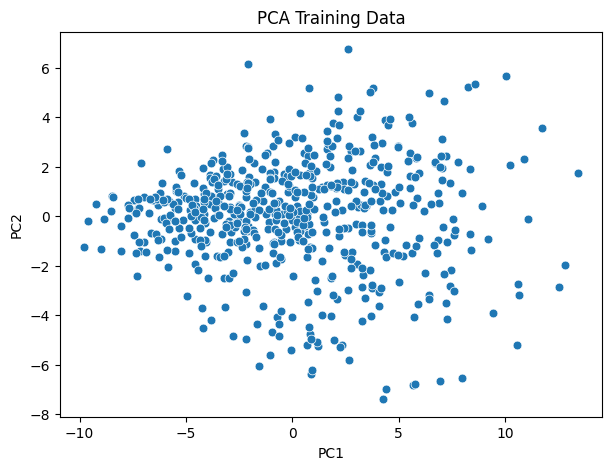

In [ ]:
# Plot PCA
data_plot = pd.DataFrame({
    "PC1": X_train_pca2[:, 0],
    "PC2": X_train_pca2[:, 1]
})

# Plot
plt.figure(figsize=(7, 5))
sb.scatterplot(
    data=data_plot,
    x="PC1",
    y="PC2",
    s=40
)
plt.title("PCA Training Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

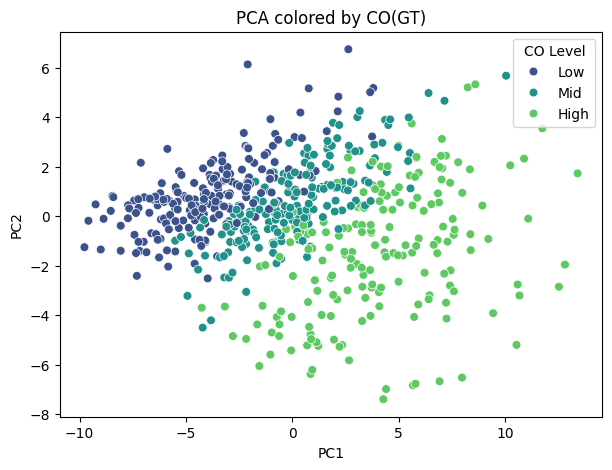

In [ ]:
# PCA Plot colored by CO(GT)
co_bins = pd.qcut(y_train, q=3, labels=["Low", "Mid", "High"])     # Create bins

data_plot = pd.DataFrame({
    "PC1": X_train_pca2[:, 0],
    "PC2": X_train_pca2[:, 1],
    "CO_bin": co_bins
})

# Plot
plt.figure(figsize=(7, 5))
sb.scatterplot(
    data=data_plot,
    x="PC1",
    y="PC2",
    hue="CO_bin",
    palette="viridis",
    s=40
)
plt.title("PCA colored by CO(GT)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="CO Level")
plt.show()

####T-SNE

In [ ]:
# Train
n_samples = min(2000, X_train_scaled_np.shape[0])     # Limit the number of samples to reduce t-SNE cost
X_subset = X_train_scaled_np[:n_samples]
y_subset = y_train.values[:n_samples]


# Initialize the t-SNE model
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_subset)     # Fit t-SNE on the subset and transform the data

# Store the t-SNE results and target values in a DataFrame
tsne_data = pd.DataFrame({
    "tSNE-1": X_tsne[:, 0],
    "tSNE-2": X_tsne[:, 1],
    "CO(GT)": y_subset
})

tsne_data.head()

,tSNE-1,tSNE-2,CO(GT)
0,-3.855200,19.891516,2.2
1,-4.446575,20.172586,1.6
2,-5.010890,20.715797,1.2
3,-17.721687,3.962257,1.2
4,-18.572338,4.054470,1.0


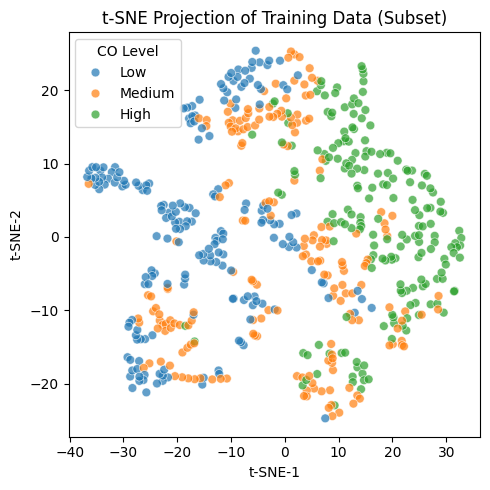

In [ ]:
# t-SNE Plot
tsne_data["CO_level"] = pd.qcut(tsne_data["CO(GT)"], q=3, labels=["Low", "Medium", "High"])

plt.figure(figsize=(5, 5))
sb.scatterplot(
    data=tsne_data,
    x="tSNE-1",
    y="tSNE-2",
    hue="CO_level",
    alpha=0.7,
    s=40
)
plt.title("t-SNE Projection of Training Data (Subset)")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.legend(title="CO Level")
plt.tight_layout()
plt.show()

####UMAP

In [ ]:
# Initialize the UMAP model
umap_model = umap.UMAP(
    n_components=2,     # Project data into 2D space
    n_neighbors=15,     # Controls local vs global structure
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_train_scaled_np)

umap_data = pd.DataFrame({
    "UMAP-1": X_umap[:, 0],
    "UMAP-2": X_umap[:, 1],
    "CO(GT)": y_train.values
})

umap_data.head()

,UMAP-1,UMAP-2,CO(GT)
0,4.107247,6.920034,2.2
1,4.175388,6.700018,1.6
2,4.123288,6.703190,1.2
3,6.216853,3.777936,1.2
4,6.287002,3.594548,1.0


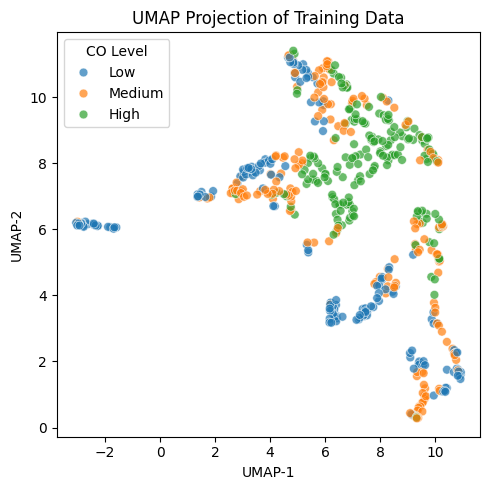

In [ ]:
# UMAP Plot
umap_data["CO_level"] = pd.qcut(umap_data["CO(GT)"], q=3, labels=["Low", "Medium", "High"])

plt.figure(figsize=(5, 5))
sb.scatterplot(
    data=umap_data,
    x="UMAP-1",
    y="UMAP-2",
    hue="CO_level",
    alpha=0.7,
    s=40,
)

plt.title("UMAP Projection of Training Data")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="CO Level")
plt.tight_layout()
plt.show()

### **Comparison**

In [ ]:
sb.set_theme(
    style="whitegrid",
    context="paper",
    palette="deep"
)

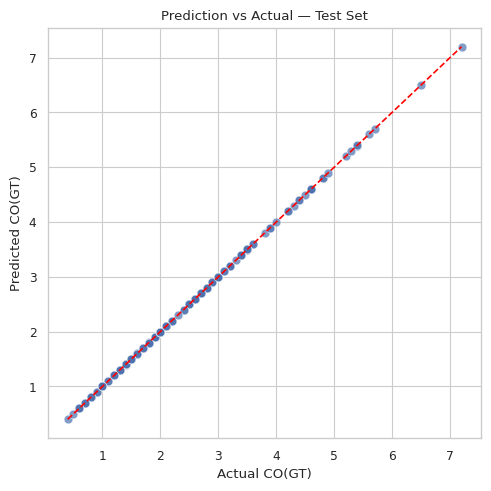

In [ ]:
# Prediction vs Actual (Test Set)
plot_data = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Scatter plot
plt.figure(figsize=(5, 5))
sb.scatterplot(
    data=plot_data,
    x="Actual",
    y="Predicted",
    s=40,
    alpha=0.7
)

# Draw the ideal prediction line (y = x)
min_v = plot_data.min().min()
max_v = plot_data.max().max()
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="red")

plt.title("Prediction vs Actual — Test Set")
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.tight_layout()
plt.show()

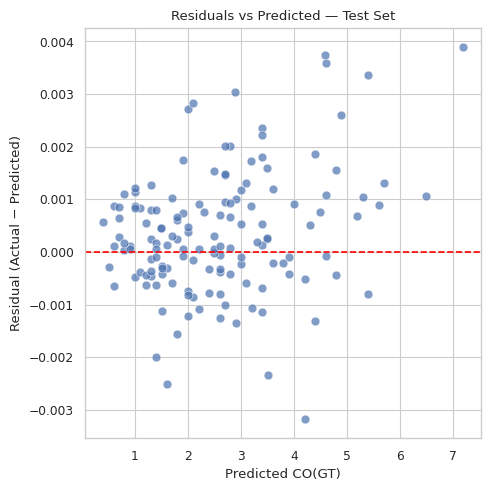

In [ ]:
# Residuals vs Predicted (Test Set)
residuals = y_test.values - y_pred

regression_data = pd.DataFrame({
    "Predicted": y_pred,
    "Residual": residuals
})

# Scatter Plot
plt.figure(figsize=(5, 5))
sb.scatterplot(
    data=regression_data,
    x="Predicted",
    y="Residual",
    s=40,
    alpha=0.7
)

plt.axhline(0, linestyle="--", color="red")     # Horizontal line at zero residual
plt.title("Residuals vs Predicted — Test Set")
plt.xlabel("Predicted CO(GT)")
plt.ylabel("Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()

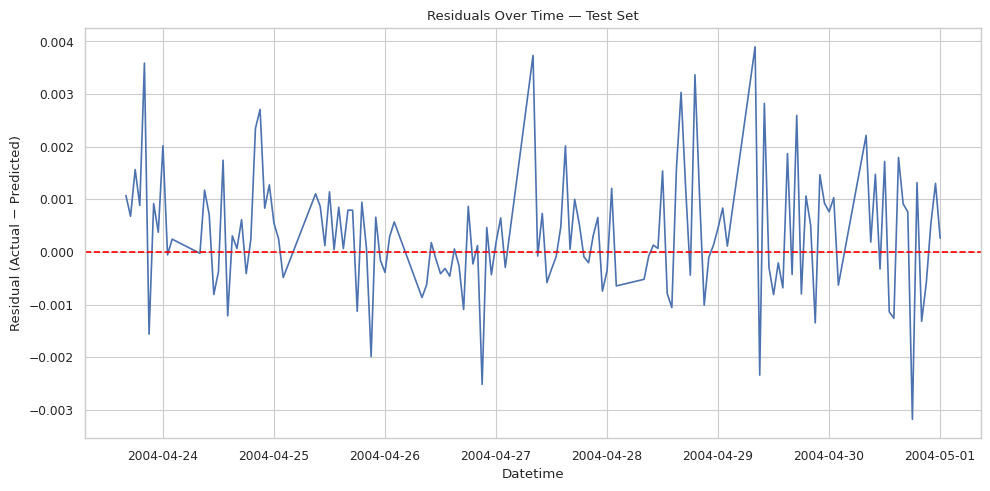

In [ ]:
# Residuals Over Time (Test Set)
split_idx_for_data = len(X_train)

time_data = pd.DataFrame({
    "Datetime": data["Datetime"].iloc[split_idx_for_data:].reset_index(drop=True),
    "Residual": residuals
})

# Line plot
plt.figure(figsize=(10, 5))
sb.lineplot(
    data=time_data,
    x="Datetime",
    y="Residual"
)

plt.axhline(0, linestyle="--", color="red")     # Horizontal line at zero residual
plt.title("Residuals Over Time — Test Set")
plt.xlabel("Datetime")
plt.ylabel("Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()

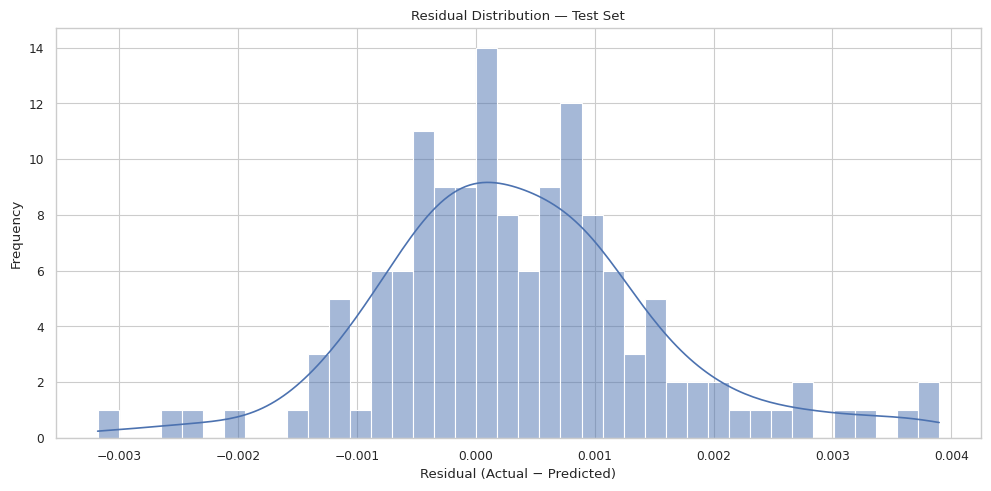

Residual mean: 0.0003568718330366713
Residual std : 0.001167768938966048


In [ ]:
# Error Distribution (Histogram of Residuals)
plt.figure(figsize=(10, 5))
sb.histplot(     # Histogram plot
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution — Test Set")
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Residual mean:", np.mean(residuals))
print("Residual std :", np.std(residuals))

In [ ]:
# RMSE Comparison
comparison_data = cv_results_data.copy().sort_values("RMSE_mean")
comparison_data["highlight"] = comparison_data["model"].apply(
    lambda x: "Best Model (Lasso)" if x == "Lasso" else "Other Models"
)
comparison_data

,model,MAE_mean,RMSE_mean,R2_mean,highlight
1,Lasso,0.032236,0.045547,0.998450,Best Model (Lasso)
0,Ridge,0.153393,0.200829,0.966703,Other Models
6,GradientBoosting,0.203438,0.273470,0.951588,Other Models
5,RandomForest,0.220079,0.291318,0.945720,Other Models
4,RegressionTree,0.290000,0.406185,0.890656,Other Models
2,KNN,0.336826,0.427834,0.879065,Other Models
3,SVR,0.396552,0.515215,0.771494,Other Models


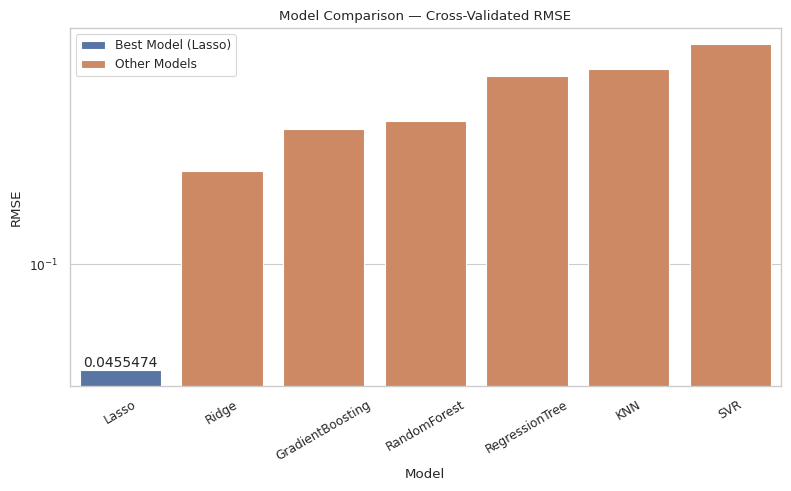

In [ ]:
# RMSE Comparison Plot
plt.figure(figsize=(8, 5))
ax = sb.barplot(
    data=comparison_data,
    x="model",
    y="RMSE_mean",
    hue="highlight",
    dodge=False
)
ax.bar_label(ax.containers[0], fontsize=10);
plt.yscale("log")
plt.title("Model Comparison — Cross-Validated RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.legend(title="")
plt.show()

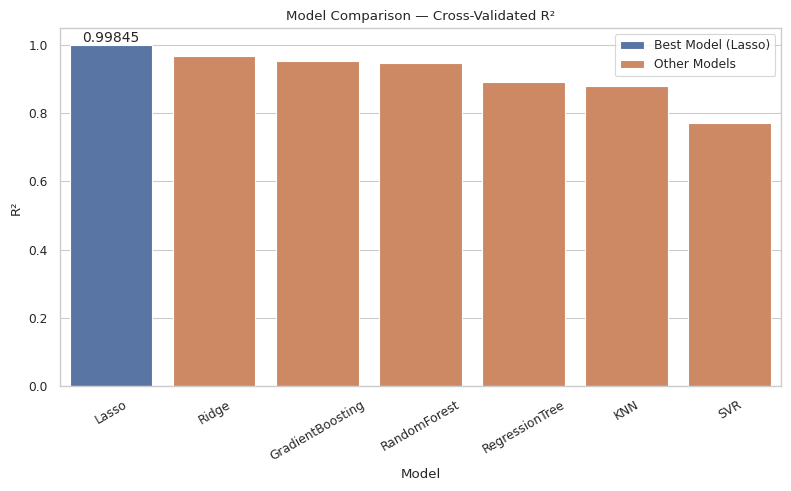

In [ ]:
# R² Comparison Plot
plt.figure(figsize=(8, 5))
ax = sb.barplot(
    data=comparison_data,
    x="model",
    y="R2_mean",
    hue="highlight",
    dodge=False
)
ax.bar_label(ax.containers[0], fontsize=10);
plt.title("Model Comparison — Cross-Validated R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.legend(title="")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()